# (노트) 과적합
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [딥러닝, 응용통계]

### 오버피팅의 개념

`-` 정의: 모형의 일반화 성능이 떨어지는 현상

- 연습문제는 잘푸는데 실전에 약하다. 
- 

### 예제소개

`-` 아래와 같은 자료가 있다고 하자. 

In [380]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1] # 합격 or 불합격 

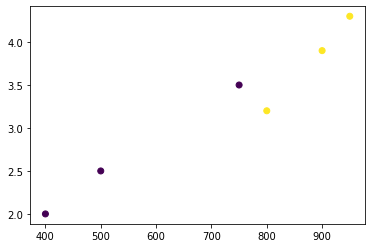

In [381]:
import matplotlib.pyplot as plt 
plt.scatter(toeic,gpa,marker='o',c=y)

`-` 토익과 학점을 바탕으로 합격/불합격을 예측하는 모형을 만들고자 한다. 아래와 같은 모형을 생각하자. 
 - (population) $y \approx v=f(u)=\frac{e^u}{1+e^u}, \quad u=\beta_0+\beta_1\times toeic +\beta_2\times gpa$
 - (sample) $y_i \approx v_i=f(u_i)=\frac{e^{u_i}}{1+e^{u_i}}, \quad u_i=\beta_0+\beta_1\times toeic_i +\beta_2\times gpa_i$

토익과 학점이 비등하게 반영되도록 하려면 토익을 1/100정도로 나누고, 학점에 2정도를 곱하면 될것 같다. 

즉 $\beta_1=\frac{1}{100}$, $\beta_2=2.00$ 와 같이 하면 적당한것 같다. 

In [386]:
import tensorflow as tf
import numpy as np 
X=np.array([toeic,gpa]).T
w=np.array([1/100,2])
b=np.array(0) 
u=X@w+b
v=np.array(tf.nn.sigmoid(u))

In [387]:
u,v

(array([ 8. , 10. , 14.5, 14.4, 16.8, 18.1]),
 array([0.99966465, 0.9999546 , 0.9999995 , 0.99999944, 0.99999995,
        0.99999999]))

$u$에서 14.5정도를 빼면 될것 같다. (즉 $\beta_0$를 14.5로 설정한다는 의미 )

In [389]:
import tensorflow as tf
import numpy as np 
X=np.array([toeic,gpa]).T
w=np.array([1/100,2])
b=np.array(-14.5) 
u=X@w+b
v=np.array(tf.nn.sigmoid(u))

In [391]:
u,v

(array([-6.5, -4.5,  0. , -0.1,  2.3,  3.6]),
 array([0.00150118, 0.01098694, 0.5       , 0.47502081, 0.90887704,
        0.97340301]))

`-` 팁: 경계선에서 $u\approx 0$ 이 되도록 만들면 $v \approx 0.5$ 가 된다. 
 - 왜? $v=\frac{e^{u}}{1+e^{u}}$이므로 $u=0$을 대입하면 $v=\frac{1}{1+1}=\frac{1}{2}$

`-` 이제 $u\approx 0$ 혹은 $v\approx 0.5$를 경계로 합격불합격을 판단하면 된다. 

경계선을 그려보자. 

$$u=0 \Longleftrightarrow  0= toeic \times \frac{1}{100} + gpa \times 2.0 -14.5 \cdots (\star)$$

$(\star)$를 만족하는 $(toeic,gpa)$의 집합을 그리면 아래와 같다. 

> Note: 그림을 위한 예비계산: $gpa=\frac{14.5-toeic\frac{1}{100}}{2}$

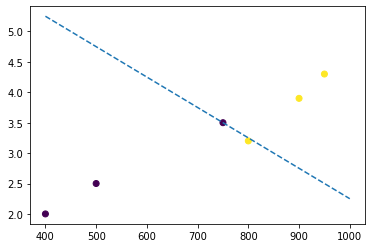

In [393]:
plt.scatter(toeic,gpa,marker='o',c=y)
_toeic=np.linspace(400,1000,1000)
_gpa=(14.5-_toeic/100)/2 # _gpa=(-b-w[0]*_toeic)/w[1]
plt.plot(_toeic,_gpa,'--')

`-` 위의 그림처럼 $(toeic,gpa)$그림도 훌륭하지만 아래와 같이 $(u,v)$로 플랏하면 신경망의 입력과 출력을 함께 볼 수 있어서 유용하다. 

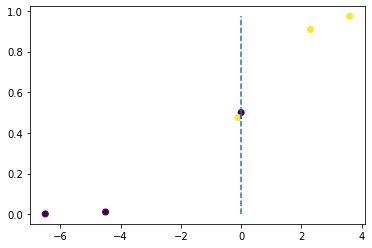

In [315]:
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')

사실상 toeic, gpa 2개의 변수가 $u$라는 하나의 변수로 압축되어서 신경망의 입력으로 들어가는 형태이다. 

신경망은 $0$을 기준으로 큰음수일수록 0에 가까운 출력이 큰양수일수록 1에 가까운 출력을 준다. 

따라서 $u$의 값이 음수인지 양수인지에 따라서 합격 불합격이 판단된다고 생각할수 있으므로 $u=0$에 해당하는 vertical line을 그어봐서 왼쪽이면 불합격, 오른쪽이면 합격으로 판단하면 된다. 

`-` $u=0$을 기준점으로 잡을수 있는것처럼 $v=0.5$를 기준선으로 잡을수도 있다. 

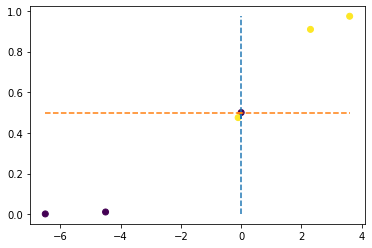

In [316]:
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')

`-` 정리를 해보자.  

`-` 모형 
 - (population) $y \approx v=f(u)=\frac{e^u}{1+e^u}, \quad u=\beta_0+\beta_1\times toeic +\beta_2\times gpa$
 - (sample) $y_i \approx v_i=f(u_i)=\frac{e^{u_i}}{1+e^{u_i}}, \quad u_i=\beta_0+\beta_1\times toeic_i +\beta_2\times gpa_i$

`-` (자료,계수값) $\to$ (그림) 

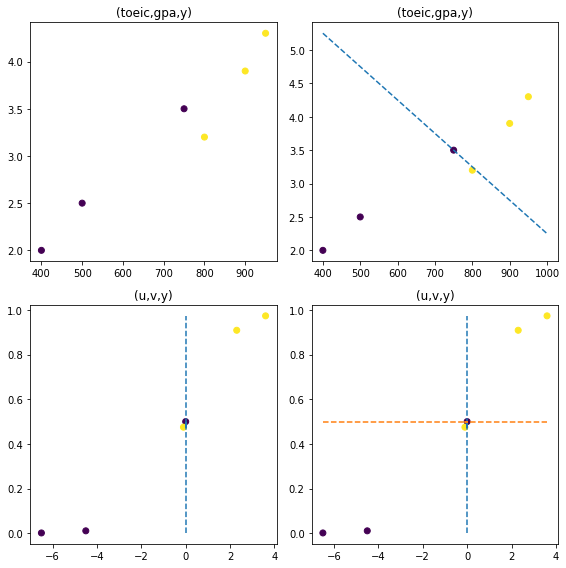

In [394]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([1/100,2])
b=np.array(-14.5) 
u=X@w+b
v=np.array(tf.nn.sigmoid(u))
_toeic=np.linspace(400,1000,1000)
_gpa=(-b-w[0]*_toeic)/w[1]
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

`-` 계수값을 바꾸면서 결과를 확인해보자. $\to$ GPA의 계수값을 상승시켜보자. 

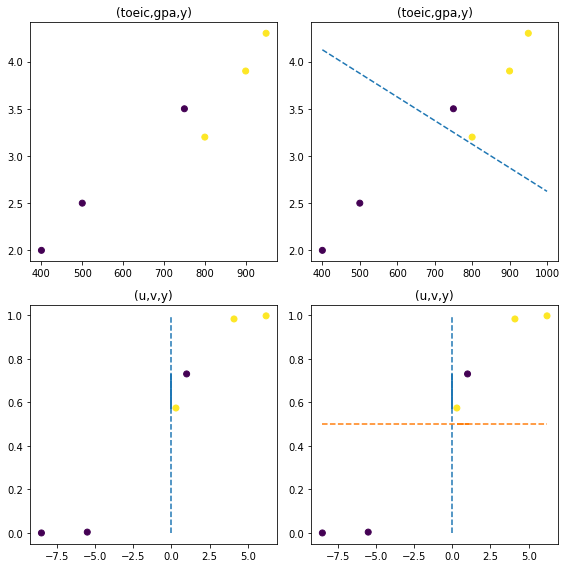

In [395]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([1/100,4])
b=np.array(-20.5) 
u=X@w+b
v=np.array(tf.nn.sigmoid(u))
_toeic=np.linspace(400,1000,1000)
_gpa=(-b-w[0]*_toeic)/w[1]
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

`-` 우측 위쪽의 그림에서 기울기가 평평해진다 $\to$ 극단적으로는 $x$축에 평행한 수직선 형태가 될듯 
 - $x$축에 평행한 수직선이라는 의미는 토익점수와 상관없이 GPA만 가지고 합격 불합격을 판단하는 구분자라는 의미

### 잘못된 분석을 하는 사례1: 너무 적은 $n$ 때문에.. 

`-` 우하향 직선이 아니라 우상향 직선을 아주 잘 그으면 100% 분리가 가능해보인다. 

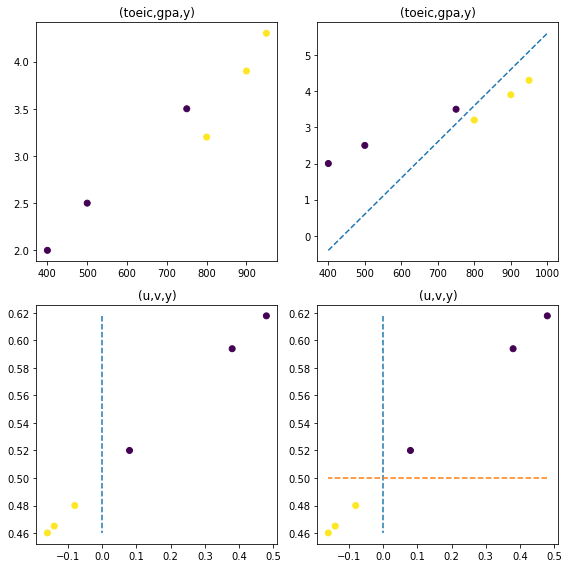

In [379]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([-2/1000,0.2])
b=np.array(0.88) 
u=X@w+b
v=np.array(tf.nn.sigmoid(u))
_toeic=np.linspace(400,1000,1000)
_gpa=(-b-w[0]*_toeic)/w[1]
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

`-` 모형 
 $$y \approx v=f(u)=\frac{e^u}{1+e^u}, \quad u=0.88+\frac{-2}{1000}\times toeic +0.2 \times gpa$$
 

토익점수가 오를수록 $u$의 값이 작아지고, $f(u)$의 값은 $0$에 가까워진다. 

극단적으로 어떤사람의 토익점수가 20만점이고, GPA=4.5라고 한다면, 

In [371]:
0.88 + -2/1000*200000+0.2*4.5 

-398.22

In [373]:
np.exp(-398.22)/(np.exp(-398.22)+1)

1.1356680725764854e-173

합격확률은 0이다. 

`-` 쉽게 말해서 잘못된 모형이다. 

`-` 하지만 훈련상황에서는 100%적중률을 보인 우수한 모형이다 $\to$ 일반화성능이 약한 모형, 즉 overfitted 된 모형 

`-` 이러한 모형이 나온 원인? 데이터가 너무 적어서.. 

`-` 해결책? 데이터를 많이.. 

### 잘못된 분석을 하는 사례2: 너무 많은 $p$ 때문에.. 

딱 봐도 처음에 분석했던 아래의 그림이 우수해보인다. 

In [396]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
y=[0,0,0,1,1,1]
X=np.array([toeic,gpa]).T
w=np.array([1/100,2])
b=np.array(-14.5) 

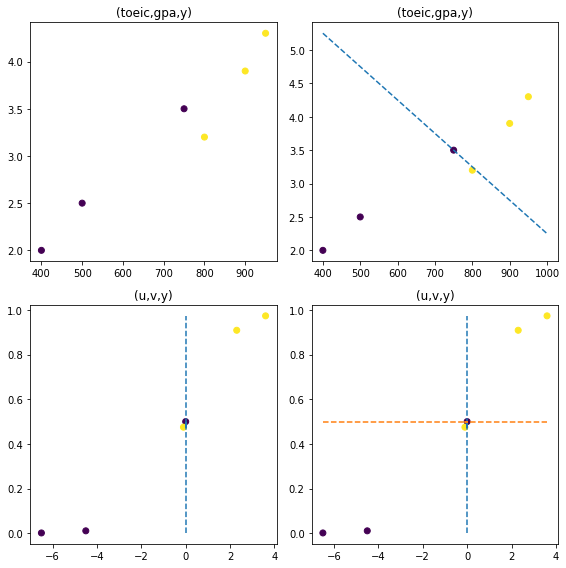

In [397]:
#collaps
u=X@w+b
v=np.array(tf.nn.sigmoid(u))
_toeic=np.linspace(400,1000,1000)
_gpa=(-b-w[0]*_toeic)/w[1]
plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(2,2,2)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(2,2,3)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.subplot(2,2,4)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)
plt.plot(u*0,v,'--')
plt.plot(u,v*0+0.5,'--')
plt.tight_layout()

욕심: 경계에 있는 값을 좀 더 잘 구분할 수 있을까? 

변수를 더 수집한다. (빅데이터? ㅋㅋㅋ)

In [421]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
boomuck=[1,0,1,0,1,0]
y=[0,0,0,1,1,1]

`-` 모형
- $y\approx v=f(u)=\frac{e^u}{1+e^u}$
- $u=w_0 + toeic \times w_1 + gpa \times w_2 + boomuck \times w_3$

In [424]:
X=np.array([toeic,gpa,boomuck]).T
w=np.array([1/100,2,-2])
b=np.array(-14.5) 

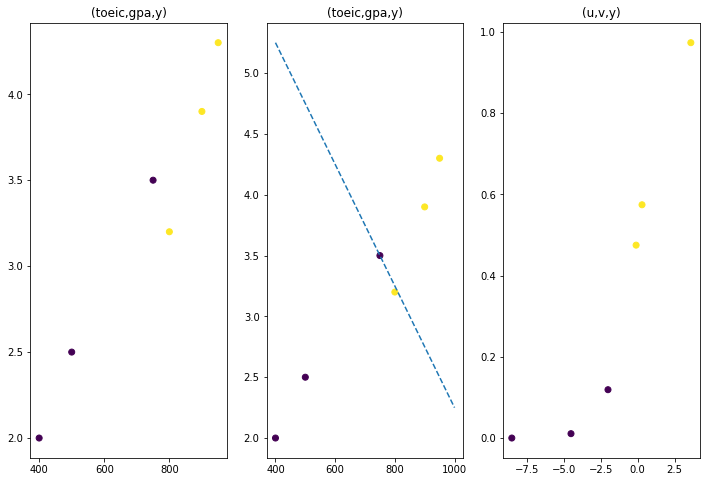

In [432]:
#collaps
u=X@w+b
v=np.array(tf.nn.sigmoid(u))
_toeic=np.linspace(400,1000,1000)
_boomuck=np.linspace(0,1,1000) ## 추가함. 
_gpa=(-b-w[0]*_toeic)/w[1] ## 수정함. 
plt.figure(figsize=(12,8))
plt.subplot(1,3,1)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.subplot(1,3,2)
plt.title("(toeic,gpa,y)")
plt.scatter(toeic,gpa,marker='o',c=y)
plt.plot(_toeic,_gpa,'--')
plt.subplot(1,3,3)
plt.title("(u,v,y)")
plt.scatter(u,v,marker='o',c=y)

구분될것 같다. 

`-` 극단적으로 부먹 vs 찍먹의 관측치가 `우연히` 아래와 같이 관측되었다면? 

In [433]:
toeic=[400,500,750,800,900,950]
gpa=[2.0,2.5,3.5,3.2,3.9,4.3]
boomuck=[0,0,0,1,0,0]
y=[0,0,0,1,1,1]

그러니까 (1) 일단 부어먹는애는 합격 (2) 찍먹 애들은 토익-학점을 보고 합불판단 이런식으로 구분하면 된다. 

`-` 저런 데이터가 우연히 얻어졌다고 주장하는것이 어거지 같은가? 

밸런스게임을 무한반복 해보자. 

- 민트초코 먹을수 있음? 없음? 
- 평생 백수로 월 250 vs 평생 직장인 월 1억 
- 평생 양치안하기 vs 평생 샤워안하기 
- ... 

원하는 숫자만큼 변수를 만들수 있다. 

이 변수를 다 넣고 적합을 시킨다면? $\to$ perfect fit

`-` 쉽게 생각하면 $n$을 크게 하면 문제가 해결될것 같은데 그렇지 않다. 

왜냐하면 모형을 안정화 시킬려면 밸런스 게임으로 부터 얻은 변수들이 사실 상관이 없다는 것을 보일 만큼 충분히 큰 숫자의 $n$을 확보해야한다. 

상황1: 밸런스게임 변수가 1개일때: 탕수육을 부어먹든지 찍어먹든지가 사실 합격 불합격 여부에 전혀 상관이 없다라는 결론을 내리고 싶다고 하자. 
 - 증명방법: 
   - 탕수육을 부어먹는 사람 100명, 부어먹지 않는사람 100명정도 확보 
   - $\to$ 관찰해보니까 각 카테고리에서 50:50 정도록 합불이 나누어짐 
   - $\to$ 탕수육을 부어먹든 찍어먹든 합격여부와는 상관없음을 결론지음
 - 한 200개 정도 샘플이 있으면 타당한 결론을 내릴 수 있다. 

상황2: 밸런스게임 변수가 2개라고 하자. 
 - 증명방법: 탕수육을 부어먹고 민트초코를 먹는 사람 100명, $\dots$ 탕수육을 부어먹지 않고 민트초코를 먹는사람 100명 확보
 - 한 400개 정도 샘플이 있으면 될것 같음. 

상황3: 밸런스게임 변수가 3개라고 하자. 
 - 한 800개 정도 샘플이 필요. 
 
상황4: 밸런스게임 변수가 $21$개 존재함. 
 - 약 $100\times 2^{21}$개의 샘플필요

In [437]:
100*2**21

209715200

요즘 관측하는 자료는 $p$의 숫자가 1000개정도는 가뿐하다. 

MNIST예제와 같이 `이미지 픽셀` $\to$ `숫자 예측`를 하는 경우 $784$개의 변수를 사용함. 

이 변수들이 각각 0과 1의 값만 가진다고 쳐도 $2^{784}$.. 

그런데 0~255의 값을 가진다면? $255^{784}$

***저주..***

> Note: 데이터의 차원이 늘어날수록 모형의 안정성을 이해서 더 많은 샘플이 필요해지고, 그래서 학습이 어려워 지는 현상을 차원의 저주라고 한다. 

### 사례1, 사례2의 정리 

사례1과 사례2는 결국 $n>>p$ 이어야 하는데 $n\approx p$ 이거나 $n<p$ 이기 때문에 생기는 문제라 볼 수 있다. 

학습이 제대로 되지 않는 상황은 $\beta_0,\beta_1,\beta_2$의 값을 엉뚱하게 추론한 것인데 이러한 일이 생기는 원인을 회귀모형으로 다시 돌아가 생각하면 자명하다. 

- $\beta_0,\beta_1,\beta_2$의 해석해는 $\bf (X^\top X)^{-1}X^\top y$ 인데 $n < p$ 일때는 역행렬이 존재하지 않으므로 해를 구하는 것이 불가능하다. 

- 해석해로 구하지 않고 수치해석적인 방법으로 해를 구하는것은 숫자가 나오긴 하지만 신뢰할 수 없다. 문제 상황과 같이 $n>>p$이 되지 못하는 경우는 $\beta_0,\beta_1,\beta_2$를 적당히 조정하여 쉽게 perfect fit을 만들 수 있고 perfect fit이 한번 발생하면 (그 값이 아무리 엉뚱한 가중치라 할지라도) 더 이상 업데이트가 일어나지 않는다 
> Note: 왜? loss 가 0이니까

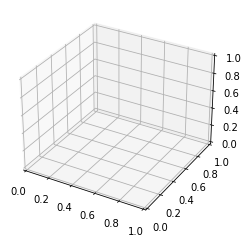

In [245]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = plt.axes(projection='3d')

In [246]:
_x,_y = _X = np.meshgrid(toeic,gpa)
_u =_x*1/100+_y*2-14.5
_v = np.array(tf.nn.sigmoid(_u))

In [247]:
ax.plot_surface(_x,_y,_v)

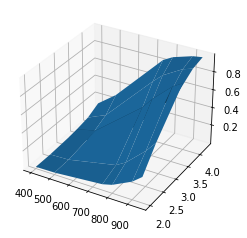

In [248]:
fig

In [142]:
_df=pd.DataFrame({'u':u,'v':v})
df=pd.concat([df,_df],axis=1)

In [143]:
sns.relplot()

,toeic,gpa,num,y,u,v,u,v
0,400,2.0,7,0,-6.5,0.001501,-6.5,0.001501
1,500,2.5,777,0,-4.5,0.010987,-4.5,0.010987
2,750,3.5,8,0,0.0,0.500000,0.0,0.500000
3,800,3.2,1,1,-0.1,0.475021,-0.1,0.475021
4,900,3.9,0,1,2.3,0.908877,2.3,0.908877
5,950,4.3,3,1,3.6,0.973403,3.6,0.973403


다음과 같이 학습했다고 하자. 

#### 사례2: 너무 큰 $p$

`-` 회귀분석 복습: $R^2$는 변수의 수가 늘어날수록 증가한다. 